## Question 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import tensorflow as tf
import os
import pandas as pd

In [ ]:
def KMeansI(data, n, k, max_iterations=1000000, tol=1e-12):
    mus = data[np.random.choice(n, k, replace=False)]
    Z = np.zeros((n, k))
    for _ in range(max_iterations):
        mus_old = mus.copy()

        # Update assignments and distances
        for i in range(n):
            dist = np.linalg.norm(data[i] - mus, axis=1)
            cluster = np.argmin(dist)
            Z[i] = np.eye(k)[cluster]

        # Update centroids
        for j in range(k):
            num = np.zeros_like(data[0])
            dem = 0
            for i in range(n):
                num += Z[i][j] * data[i]
                dem += Z[i][j]
            mus[j] = num / dem if dem != 0 else np.zeros_like(data[0])

        if np.max(np.abs(mus - mus_old)) < tol:
            break
    return mus, Z

In [ ]:
def KMeansII(data, n, k, max_iterations=1000000, tol=1e-12):
    Z = np.eye(k)[np.random.choice(k, n)]
    mus = np.zeros((k, data.shape[1]))

    for _ in range(max_iterations):
        mus_old = mus.copy()

        # Update centroids
        mus = np.dot(Z.T, data) / np.sum(Z, axis=0)[:, None]

        # Update assignments
        distances = np.linalg.norm(data[:, None] - mus, axis=2)
        Z = np.zeros_like(Z)
        Z[np.arange(n), np.argmin(distances, axis=1)] = 1

        if np.max(np.abs(mus - mus_old)) < tol:
            break

    return mus, Z


In [ ]:
os.environ["KAGGLE_USERNAME"] = "abhinavreddygutha"
os.environ["KAGGLE_KEY"] = "6ed6c2699643f5946cb44c75ccf9ae57"

In [ ]:
!kaggle datasets download -d janithwanni/old-faithful

  0% 0.00/1.55k [00:00<?, ?B/s]
100% 1.55k/1.55k [00:00<00:00, 2.62MB/s]


In [ ]:
!unzip old-faithful.zip

Archive:  old-faithful.zip
  inflating: faithful.csv            


In [ ]:
data = pd.read_csv('faithful.csv')

In [ ]:
data = data.drop(["Unnamed: 0"], axis=1)

In [ ]:
data = data.to_numpy()

In [ ]:
mus1, Z1 = KMeansI(data, len(data), 2)

In [ ]:
mus1

array([[ 2.09433   , 54.75      ],
       [ 4.29793023, 80.28488372]])

In [ ]:
mus2, Z2 = KMeansII(data, len(data), 2)

In [ ]:
mus2

array([[ 4.29793023, 80.28488372],
       [ 2.09433   , 54.75      ]])

In [ ]:
def plotClusters(data, mus):
  plt.figure(figsize=(8, 6))
  plt.scatter(data[:, 0], data[:, 1], cmap='viridis')
  plt.scatter(mus[:, 0], mus[:, 1], marker='X', color='red', s=100)
  plt.xlabel('eruptions')
  plt.ylabel('waitings')
  plt.title('Old Faithful Clustering')
  plt.show()

<ipython-input-14-bbf35a48d39e>:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data[:, 0], data[:, 1], cmap='viridis')


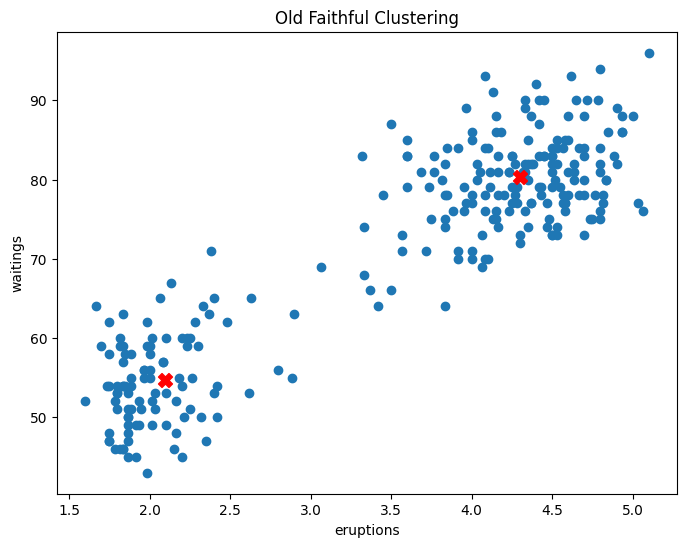

In [ ]:
plotClusters(data, mus1)

<ipython-input-14-bbf35a48d39e>:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data[:, 0], data[:, 1], cmap='viridis')


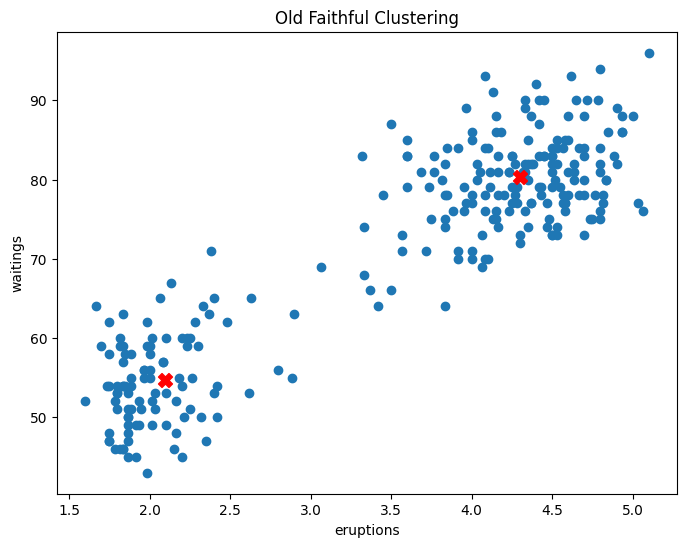

In [ ]:
plotClusters(data, mus2)

## Question 2

#### Part A

In [ ]:
def gaussian_2d(mu, sigma, num_points=1000):
    x, y = np.random.multivariate_normal(mu, sigma, num_points).T
    return x, y

In [ ]:
def gaussianValue(point, mu, sigma):
    # Calculate the value of the Gaussian function for a given point, mean, and covariance matrix
    d = len(point)
    det = np.linalg.det(sigma)
    inv = np.linalg.inv(sigma)
    coefficient = 1 / np.sqrt((2 * np.pi) ** d * det)
    exponent = -0.5 * np.dot(np.dot((point - mu).T, inv), (point - mu))
    return coefficient * np.exp(exponent)

In [ ]:
def GMMPoints(mu, sigma, num_points):
    # Generate correlated points using the Cholesky decomposition
    L = np.linalg.cholesky(sigma)
    points = np.random.normal(size=(num_points, len(mu)))
    points = points @ L.T  # Apply the Cholesky decomposition

    # Shift the points by the mean
    points += mu
    num_points = int(np.sqrt(num_points))
    # Extract x, y, and z coordinates
    x = points[:, 0].reshape((num_points, num_points))
    y = points[:, 1].reshape((num_points, num_points))
    z = multivariate_normal(mu, sigma).pdf(points).reshape((num_points, num_points))

    return x, y, z

In [ ]:
def plot_contours(X1, Y1, Z1, X2, Y2, Z2, X3, Y3, Z3):
    plt.figure(figsize=(12, 8))
    plt.contour(X1, Y1, Z1, colors='r', linestyles='solid')
    plt.contour(X2, Y2, Z2, colors='g', linestyles='solid')
    plt.contour(X3, Y3, Z3, colors='b', linestyles='solid')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Contours of Gaussian Distributions')
    plt.legend(['X Distribution', 'Y Distribution', 'Z Distribution'])
    plt.grid(True)
    plt.show()

In [ ]:
mu1 = np.array([1, 2])
sigma1 = np.array([[2, 0], [0, 1]])

mu2 = np.array([-5, 7])
sigma2 = np.array([[1, 0], [0, 2]])

mu3 = np.array([2, 8])
sigma3 = np.array([[2, 0.5], [0.5, 1]])

X1, Y1, Z1 = GMMPoints(mu1, sigma1, 1600)
X2, Y2, Z2 = GMMPoints(mu2, sigma2, 2500)
X3, Y3, Z3 = GMMPoints(mu3, sigma3, 3600)

In [ ]:
X1

array([[ 1.60654993,  1.58231509,  1.49082235, ...,  0.96876432,
         1.96782047,  1.40852762],
       [ 0.84626484, -1.08120929,  2.87690332, ...,  1.57429898,
         3.20342063,  3.59866012],
       [ 0.63771762,  2.70173244, -0.05194501, ...,  1.06905063,
         2.42743735, -0.0776228 ],
       ...,
       [-0.62917894,  2.46834984, -0.18120493, ...,  1.33770283,
        -0.98863514,  1.31335953],
       [ 3.12747962,  2.34356544,  0.20166559, ...,  0.35999325,
         0.68248644,  2.2283677 ],
       [ 3.40587048,  2.72910044, -1.51162389, ...,  2.6446286 ,
         3.7823704 , -0.10465384]])

In [ ]:
Y1

array([[ 0.42846798, -0.4039777 ,  3.74568917, ...,  3.38515764,
         1.7685782 ,  1.6457166 ],
       [ 0.57622355,  2.74878258,  2.20718561, ...,  2.93631325,
         4.00487114,  3.08450186],
       [ 3.14137407,  2.48375641,  3.4578204 , ...,  3.8522511 ,
         1.8892036 ,  2.52011601],
       ...,
       [ 3.5988126 ,  1.62297834,  2.49639368, ...,  3.37981892,
         2.15603678,  1.92781838],
       [ 1.10160562,  1.21381718,  2.87705357, ...,  1.15106885,
         1.73294494,  0.55581353],
       [ 3.12083131,  1.6545098 ,  1.15534844, ...,  2.57989593,
         5.36809491,  0.62096888]])

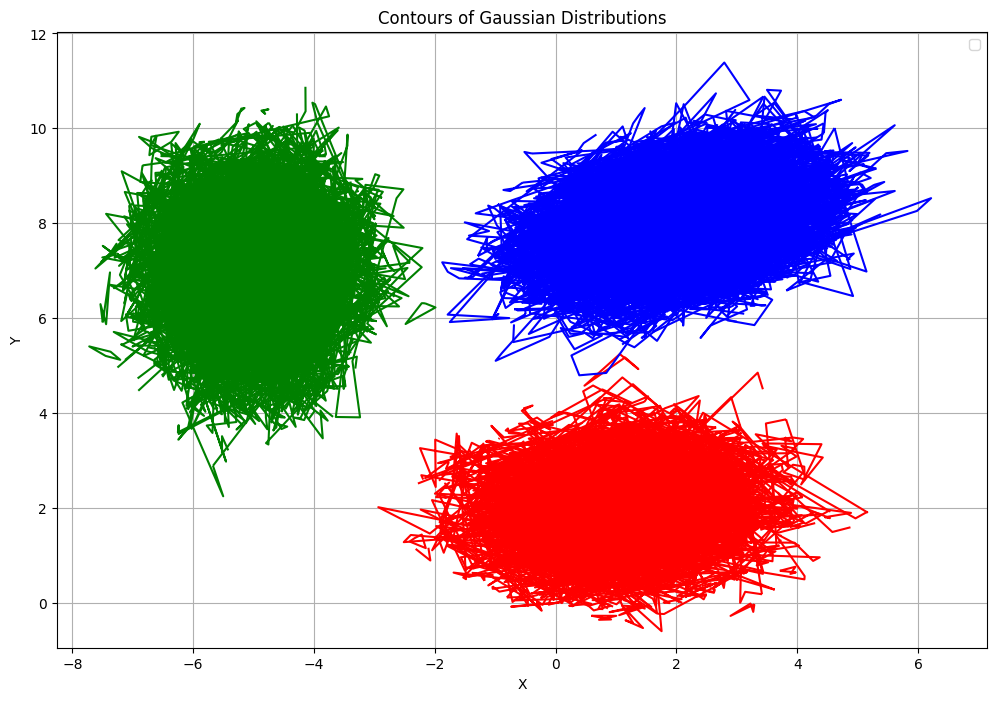

In [ ]:
plot_contours(X1, Y1, Z1, X2, Y2, Z2, X3, Y3, Z3)

In [ ]:
n = len(X1)
Points = np.empty((0, 2))
for i in range(n):
    for j in range(n):
        Points = np.vstack((Points, np.array([X1[i][j], Y1[i][j]])))
n = len(X2)
for i in range(n):
  for j in range(n):
        Points = np.vstack((Points, np.array([X2[i][j], Y2[i][j]])))
n = len(X3)
for i in range(n):
  for j in range(n):
        Points = np.vstack((Points, np.array([X3[i][j], Y3[i][j]])))

In [ ]:
n = len(X1)
PointsWithZi = np.empty((0, 3))
for i in range(n):
    for j in range(n):
        PointsWithZi = np.vstack((PointsWithZi, np.array([X1[i][j], Y1[i][j], 1])))
n = len(X2)
for i in range(n):
    for j in range(n):
        PointsWithZi = np.vstack((PointsWithZi, np.array([X2[i][j], Y2[i][j], 2])))
n = len(X3)
for i in range(n):
    for j in range(n):
        PointsWithZi = np.vstack((PointsWithZi, np.array([X3[i][j], Y3[i][j], 3])))

In [ ]:
Points = np.random.permutation(Points)

In [ ]:
len(Points)

7700

In [ ]:
PointsWithZi

array([[ 1.60654993,  0.42846798,  1.        ],
       [ 1.58231509, -0.4039777 ,  1.        ],
       [ 1.49082235,  3.74568917,  1.        ],
       ...,
       [ 2.28385468,  8.07141891,  3.        ],
       [ 1.33683181,  6.9549149 ,  3.        ],
       [ 2.45903551,  7.96468366,  3.        ]])

In [ ]:
# Points = Points.astype(np.float32)

#### Part B

In [ ]:
mus = np.array([[1, 2], [-5, 7], [2, 8]])
sigmas = np.array([[[2, 0], [0, 1]], [[1, 0], [0, 2]], [[2, 0.5], [0.5, 1]]])

In [ ]:
def Clustering(Points, mus, sigmas):
    num_clusters = len(mus)
    ClusteredPoints = np.empty((0, 3))  # Ensure consistent number of columns
    for point in Points:
        cluster = 0
        max_val = 0
        for i in range(num_clusters):
            val = gaussianValue(point, mus[i], sigmas[i])
            if val > max_val:
                cluster = i + 1
                max_val = val
        ClusteredPoints = np.vstack((ClusteredPoints, np.hstack((point, cluster))))  # Ensure consistent number of columns
    return ClusteredPoints

In [ ]:
ClusteredPoints = Clustering(Points, mus, sigmas)

In [ ]:
ClusteredPoints

array([[ 0.98322121,  9.07568833,  3.        ],
       [-3.58113837,  8.7701018 ,  2.        ],
       [-0.32721462,  3.27699932,  1.        ],
       ...,
       [-5.19447441,  7.36320098,  2.        ],
       [ 3.07857262,  0.55453157,  1.        ],
       [-1.43461029,  6.03388112,  3.        ]])

In [ ]:
def clusterPlot(ClusteredPoints):
    num_clusters = int(np.max(ClusteredPoints[:, -1]))
    plt.figure(figsize=(8, 6))
    for i in range(1, num_clusters + 1):
        region = ClusteredPoints[ClusteredPoints[:, -1] == i]
        plt.scatter(region[:, 0], region[:, 1], label=f'Region {i}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Points Clustering')
    plt.legend()
    plt.grid(True)
    plt.show()

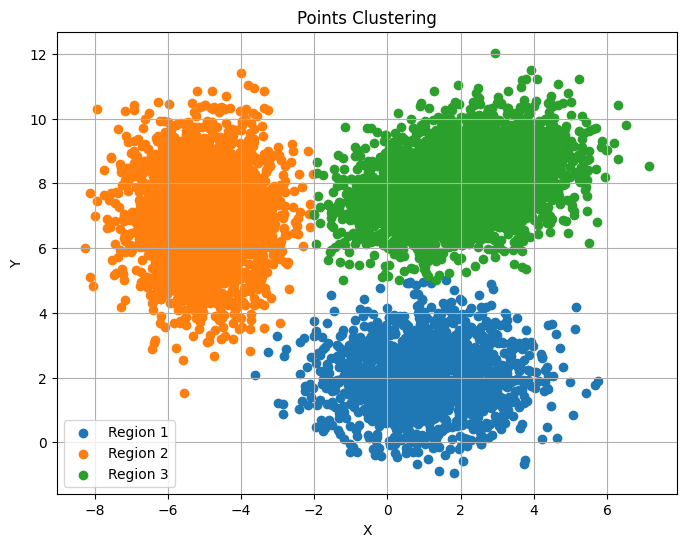

In [ ]:
clusterPlot(ClusteredPoints)

## Question 3

#### Part A

In [ ]:
def initialize_parameters(k, data):
    n, d = data.shape
    mus, _ = KMeansI(data, n, k)  # Took the initial means values from the KMeans result
    sigmas = np.array([np.eye(d) for _ in range(k)])
    Pis = np.array([0.2, 0.4, 0.4])
    return mus, sigmas, Pis

In [ ]:
def expectation_step(data, mus, sigmas, Pis):
    k = len(mus)
    n = len(data)
    d = data.shape[1]
    gamma = np.zeros((n, k))

    for i in range(k):
        gamma[:, i] = Pis[i] * multivariate_normal.pdf(data, mean=mus[i], cov=sigmas[i])

    gamma = gamma / np.sum(gamma, axis=1, keepdims=True)

    return gamma

In [ ]:
def maximization_step(data, gamma):
    n, d = data.shape
    k = gamma.shape[1]

    Nk = np.sum(gamma, axis=0)

    mus = np.dot(gamma.T, data) / Nk[:, None]

    sigmas = np.zeros((k, d, d))
    for i in range(k):
        diff = data - mus[i]
        cov_sum = np.zeros((d, d))
        for j in range(n):
            cov_sum += gamma[j, i] * (diff[j].reshape(-1, 1) @ diff[j].reshape(1, -1))
        sigmas[i] = cov_sum / Nk[i]

    Pis = Nk / n

    return mus, sigmas, Pis

In [ ]:
def calculate_log_likelihood(data, mus, sigmas, Pis):
    k = len(mus)
    likelihood = np.zeros(len(data))

    for i in range(k):
        likelihood += Pis[i] * multivariate_normal.pdf(data, mean=mus[i], cov=sigmas[i])

    return np.sum(np.log(likelihood))

In [ ]:
def calculate_parameter_change(old_parameters, new_parameters):
    parameter_change = sum(np.linalg.norm(old_param - new_param) for old_param, new_param in zip(old_parameters, new_parameters))
    return parameter_change

In [ ]:
def log_likelihood(data, means, covariances, weights, gamma):
    num_samples = len(data)
    num_components = len(means)
    log_likelihood_value = 0.0

    for i in range(num_samples):
        for j in range(num_components):
            log_likelihood_value += gamma[i, j] * (np.log(weights[j]) + multivariate_normal.logpdf(data[i], mean=means[j], cov=covariances[j]) - np.log(gamma[i, j]))

    return log_likelihood_value

In [ ]:
def EM_algorithm(data, k, max_iter=1000000000, tol=1e-12):
    mus, sigmas, Pis = initialize_parameters(k, data)

    prev_parameters = (mus.copy(), sigmas.copy(), Pis.copy())
    log_likelihood_values = []
    for i in range(max_iter):
        gamma = expectation_step(data, mus, sigmas, Pis)
        mus, sigmas, Pis = maximization_step(data, gamma)

        log_likelihood_values.append(log_likelihood(data, mus, sigmas, Pis, gamma))

        parameter_change = calculate_parameter_change(prev_parameters, (mus, sigmas, Pis))
        if parameter_change < tol:
            break

        prev_parameters = (mus.copy(), sigmas.copy(), Pis.copy())

    return mus, sigmas, Pis, log_likelihood_values

In [ ]:
means, covariances, weights, log_likelihood_values = EM_algorithm(Points, 3)

In [ ]:
means

array([[-5.00292161,  6.97861343],
       [ 1.99053309,  7.99208449],
       [ 1.03637525,  2.02015759]])

In [ ]:
weights

array([0.32450729, 0.46752891, 0.2079638 ])

In [ ]:
covariances

array([[[0.97575958, 0.02064739],
        [0.02064739, 1.98907157]],

       [[1.99514728, 0.43933543],
        [0.43933543, 0.97768294]],

       [[1.95735059, 0.02548749],
        [0.02548749, 0.98187864]]])

In [ ]:
def plotLikelihood(log_likelihood_values):
  x = []
  for i in range(len(log_likelihood_values)):
    x.append(i+1)
  plt.figure(figsize=(8,6))
  plt.plot(x, log_likelihood_values)
  plt.xlabel('Iteration Count')
  plt.ylabel('Log Likelihood Values')
  plt.title('Log Likelihood Update in each iteration')
  plt.show()

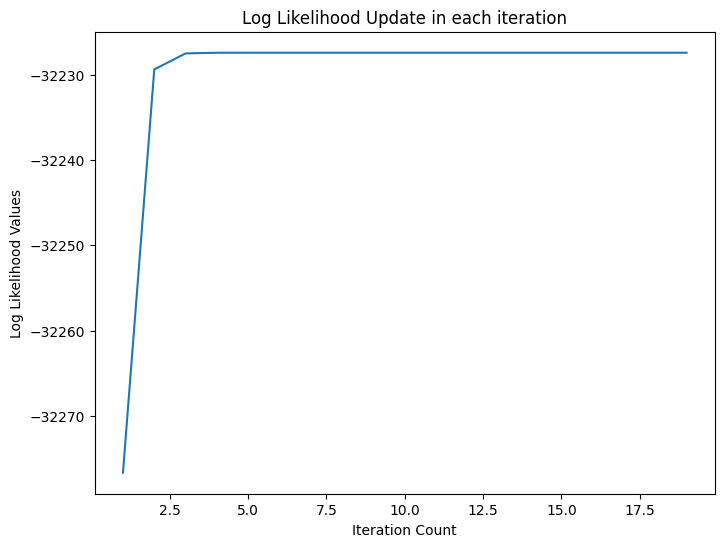

In [ ]:
plotLikelihood(log_likelihood_values)